# Machine Translation - Inference

Uncomment this if you are using Colab. Please reserve at least 80GB storage.

In [1]:
# from google.colab import drive
# drive.mount('/content/drive')

In [2]:
# cd /content/drive/MyDrive/Machine Learning/Project

In [2]:
import os, json, math, time
import dotenv
from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    DataCollatorForSeq2Seq,
    Seq2SeqTrainingArguments,
    Seq2SeqTrainer,
    EarlyStoppingCallback,
    AutoModelForSeq2SeqLM,
)
import torch
import numpy as np
import random
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import jsonlines

dotenv.load_dotenv('.env')

True

## Load Dataset WMT17

Device space limitation.

In [4]:
SUPPORTED_LANGS = ['zh-en'] #'cs-en', 'de-en', 'fi-en', 'lv-en', 'ru-en', 'tr-en', ]
lang_map = {
        'en': 'en_XX',
        'zh': 'zh_CN',
        'cs': 'cs_CZ',
        'de': 'de_DE',
        'fi': 'fi_FI',
        'lv': 'lv_LV',
        'ru': 'ru_RU',
        'tr': 'tr_TR',
    }
model_map = {
    'mbart': 'facebook/mbart-large-50-many-to-many-mmt',
    'opus-mt': 'Helsinki-NLP/opus-mt-zh-en',
    'nllb': 'facebook/nllb-200-distilled-1.3B',
    't5-small': 'google-t5/t5-small',
}
# Set the best model parameters here!
model_params = {
    'mbart': {'num_train': 2048},
    'opus-mt': {'num_train': 2048},
    'nllb': {'num_train': 2048},
    't5-small': {'num_train': 2048},
}

## Load Pretrained Model.

| Model key | HF model id                              | # Params | Arch.                     | Languages             | Pre-train data        | Tokeniser           | Requires prompt prefix?    | Size on disk |
| --------- | ---------------------------------------- | -------- | ------------------------- | --------------------- | --------------------- | ------------------- | -------------------------- | ------------ |
| mbart     | facebook/mbart-large-50-many-to-many-mmt | 610 M    | Transformer-large (12-12) | 50 langs, any→any     | CC25 + mined data     | SentencePiece 250 k | No (src/tgt codes in call) | ~2.3 GB      |
| opus-mt   | Helsinki-NLP/opus-mt-zh-en               | 74 M     | Transformer-base (6-6)    | zh → en only          | OPUS corpus           | SentencePiece 32 k  | No                         | ~298 MB      |
| nllb      | facebook/nllb-200-distilled-1.3B         | 1.3 B    | Transformer (12-12, MoE)  | 200 langs, any→any    | NLLB-200 corpus       | SentencePiece 256 k | No                         | ~5 GB        |
| t5-small  | google-t5/t5-small                       | 60 M     | Encoder-decoder (6-6)     | any pair in pre-train | C4 + downstream tasks | SentencePiece 32 k  | Yes ("translate X to Y:")  | ~242 MB      |


In [5]:
def build_model(model_name, src_lang, tgt_lang):
    model_name = model_map[model_name]
    tok = AutoTokenizer.from_pretrained(model_name, src_lang=src_lang, tgt_lang=tgt_lang, cache_dir='./cache')
    model = AutoModelForSeq2SeqLM.from_pretrained(model_name, cache_dir='./cache')
    return tok, model


In [6]:
import random
import os
import numpy as np
import torch

def seed_all(seed: int = 42):
    # 1. Python builtin
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)

    # 2. NumPy
    np.random.seed(seed)

    # 3. PyTorch
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    print(f"[seed_all] Global random seed set to {seed}")

## Load MT Metrics

In [7]:
from evaluate import load

bleu = load("sacrebleu", cache_dir='./cache')
chrf = load("chrf", cache_dir='./cache')


## Preprocess Datasets

In [8]:
def split_train_test(full_train, num_trains, num_test, num_val):
    indices = random.sample(range(len(full_train)), num_trains + num_test + num_val)
    raw_train = full_train.select(indices[:num_trains])
    raw_test = full_train.select(indices[num_trains:num_trains + num_test])
    raw_val = full_train.select(indices[num_trains + num_test:])
    return raw_train, raw_test, raw_val


In [9]:
def flip_dataset(raw, src, tgt):
    def flip(batch):
        batch["translation"] = {src: batch["translation"][tgt],
                                tgt: batch["translation"][src]}
        return batch
    return raw.map(flip, batched=False)


In [10]:
def clean_memory():
    import torch, gc
    if torch.cuda.is_available():
        torch.cuda.empty_cache()  # 把未用缓存还给 CUDA
    elif torch.backends.mps.is_available():
        torch.mps.empty_cache()   # 把未用缓存还给 CUDA
    gc.collect()               # 再让 Python 回收一次

In [11]:
def train_model(model_name: str, src: str, tgt: str, num_train=10, num_test=10, num_val=10):
    need_prompt = model_name.startswith('t5')
    data = load_dataset("wmt17", name="-".join([src, tgt]), split="train", cache_dir='./cache')

    lang_src = lang_map[src]
    lang_tgt = lang_map[tgt]
    tok, model = build_model(model_name, lang_src, lang_tgt)

    num_train_epochs = 10
    max_src, max_tgt = 128, 128

    def compute_metrics(eval_preds):
        preds, labels = eval_preds
        labels = np.where(labels != -100, labels, tok.pad_token_id)
        pred_str = tok.batch_decode(preds, skip_special_tokens=True)
        label_str = tok.batch_decode(labels, skip_special_tokens=True)
        bleu_score  = bleu.compute(predictions=pred_str,
                                    references=[[r] for r in label_str])["score"]
        chrf_score  = chrf.compute(predictions=pred_str,
                                    references=label_str)["score"]

        return {"bleu": bleu_score, "chrf": chrf_score}

    def encode(ex):
        en_sent = [item[src] for item in ex["translation"]]
        zh_sent = [item[tgt] for item in ex["translation"]]
        if need_prompt:
            # T5 is the google model that needs a prompt.
            en_sent = ["Translate from English to Chinese: " + item for item in en_sent]

        # 一次调用同时编码源端和目标端
        model_inputs = tok(
            en_sent,
            text_target=zh_sent,
            max_length=max_src,
            truncation=True,
            padding=False,          # 动态 padding，由 data_collator 完成
        )
        return model_inputs

    raw_train, raw_test, raw_val = split_train_test(data,
                                                    num_trains=num_train, num_test=num_test, num_val=num_val)
    # Why we tokenize the split instead of data? Since data is very large, and we only use a small part of it!!
    # So 3 times tokenizations is OK.
    tokenised_train = raw_train.map(encode, batched=True)
    tokenised_val = raw_val.map(encode, batched=True)
    tokenised_test = raw_test.map(encode, batched=True)

    data_coll = DataCollatorForSeq2Seq(tok, model=model)

    args = Seq2SeqTrainingArguments(
        # output_dir='/content/output',
        eval_strategy="steps",
        eval_steps=500,
        logging_steps=100,
        save_steps=500,
        per_device_train_batch_size=4,
        per_device_eval_batch_size=4,
        gradient_accumulation_steps=4,
        learning_rate=3e-5,
        num_train_epochs=num_train_epochs,
        predict_with_generate=True,
        generation_max_length=max_tgt,
        save_total_limit=2,
        load_best_model_at_end=True,
        metric_for_best_model="bleu",
        greater_is_better=True,
        report_to="none",
        fp16=True,
    )

    trainer = Seq2SeqTrainer(
        model=model,
        args=args,
        train_dataset=tokenised_train,
        eval_dataset=tokenised_val,
        processing_class=tok,
        data_collator=data_coll,
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
    )
    trainer.train()
    return model, tok


## Run Inference

Obtain the input setences.

In [12]:
dataset = load_dataset('wmt17', 'zh-en', split='test', cache_dir='./cache')

In [13]:
seed_all(111) # Set a seed to 111.

[seed_all] Global random seed set to 111


In [14]:
len(dataset)

2001

In [15]:
num_inputs = 5 # Fixed to 5.

input_data = dataset.select(random.choices(range(len(dataset)), k=num_inputs))
len(input_data)

5

In [16]:
input_data

Dataset({
    features: ['translation'],
    num_rows: 5
})

In [17]:
def get_avail_device():
    if torch.cuda.is_available():
        device = torch.device("cuda")
    elif torch.mps.is_available():
        device = torch.device("mps")
    else:
        device = torch.device("cpu")
    return device

In [18]:
import torch
from tqdm.auto import tqdm

def translate(model, tok, input_data, src='zh'):
    model.eval()
    device = get_avail_device()

    # 1. 生成参数（可按需调）
    gen_kwargs = {
        "max_length": 64,
        "num_beams": 4,
        "early_stopping": True,
    }

    out_f = []

    for sample in tqdm(input_data, desc="Translating"):
        zh = sample["translation"][src]
        inputs = tok(zh, return_tensors="pt").to(device)

        with torch.no_grad():
            pred = model.generate(**inputs, **gen_kwargs)

        hyp = tok.decode(pred[0], skip_special_tokens=True)
        out_f.append(hyp.strip())

    return out_f


Run each model.

In [19]:
tgt, src = 'en', 'zh'

translation_results = {'tgt': [sample['translation'][tgt] for sample in input_data],
                       'src': [sample['translation'][src] for sample in input_data]}

for key in model_map:
    num_train = model_params[key].get("num_train", 32)
    model, tok = train_model(key, src='zh', tgt='en', num_train=num_train, num_test=20)
    translation_results[key] = translate(model, tok, input_data, src)

Map:   0%|          | 0/10 [00:00<?, ? examples/s]

/Users/fengcong/miniconda3/envs/py312/lib/python3.12/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Step,Training Loss,Validation Loss


KeyboardInterrupt: 

In [ ]:
df = pd.DataFrame(translation_results)
df.to_csv('./translation_results.csv', index=False)

## Dimension Reduction & Clustering

In [3]:
df = pd.read_csv('./translate_result.csv')

In [5]:
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
import umap
import matplotlib.pyplot as plt
import seaborn as sns

model_map = {
    'mbart': 'facebook/mbart-large-50-many-to-many-mmt',
    'opus-mt': 'Helsinki-NLP/opus-mt-zh-en',
    'nllb': 'facebook/nllb-200-distilled-1.3B',
    't5-small': 'google-t5/t5-small',
}

# 假设你的 DataFrame 长这样：
# | tgt | pred_modelA | pred_modelB | pred_modelC | ...

# 1. 收集所有句子 + 标签
sentences, labels, markers = [], [], []   # markers: 'gt' 或模型名
for idx, row in df.iterrows():
    sentences.append(row["tgt"])
    labels.append(f"sample{idx}")
    markers.append("gt")          # ground-truth
    for model_name in model_map:
        if model_name in df.columns:
            sentences.append(row[model_name])
            labels.append(f"sample{idx}")
            markers.append(model_name)

/Users/fengcong/miniconda3/envs/py312/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


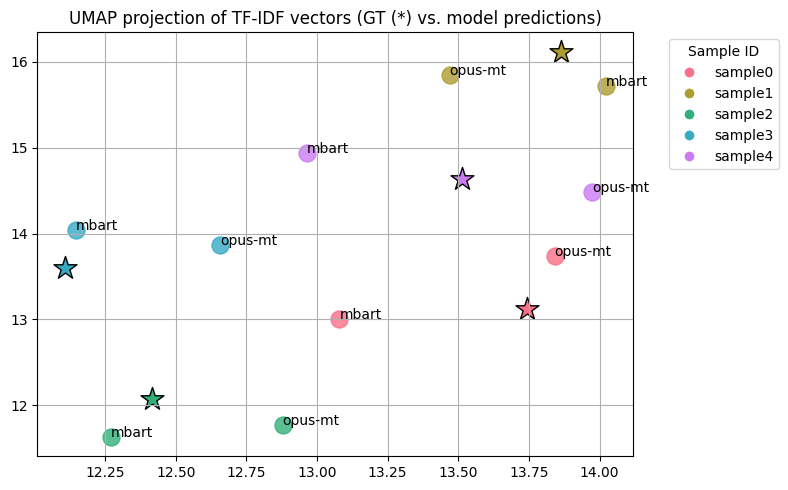

In [17]:
# 2. TF-IDF 向量化
vectorizer = TfidfVectorizer(lowercase=True, stop_words=None, max_features=20_000)
X = vectorizer.fit_transform(sentences)   # shape: (n_sent, n_features)
fontsize = 10
S = 150

# 3. UMAP 降维
reducer = umap.UMAP(n_neighbors=5, min_dist=0.1, metric="cosine", random_state=42)
XY = reducer.fit_transform(X)             # shape: (n_sent, 2)

# 4. 画图
plt.figure(figsize=(8, 5))
unique_samples = sorted(set(labels))
palette = sns.color_palette("husl", n_colors=len(unique_samples))
color_map = {sam: palette[i] for i, sam in enumerate(unique_samples)}

for i, (x, y) in enumerate(XY):
    color = color_map[labels[i]]
    if markers[i] == "gt":        # 五角星
        plt.scatter(x, y, marker="*", s=S*2, c=[color], edgecolor="black")
    else:                         # 模型预测
        plt.scatter(x, y, c=[color], s=S, alpha=0.8)
        # 在点旁边写模型名（只写一次，防止重叠）
        plt.text(x, y, markers[i], fontsize=fontsize, ha="left")

# 图例：颜色 = 样本 ID
legend_elements = [plt.Line2D([0], [0], marker="o", color="w",
                              markerfacecolor=color_map[sam], markersize=8, label=sam)
                   for sam in unique_samples]
plt.legend(handles=legend_elements, title="Sample ID", bbox_to_anchor=(1.05, 1), fontsize=fontsize, loc="upper left")
plt.title("UMAP projection of TF-IDF vectors (GT (*) vs. model predictions)")
plt.tight_layout()
plt.grid(True)
plt.savefig('./cluster.jpg')

In [18]:
vectorizer.vocabulary_

{'we': np.int64(121),
 'were': np.int64(122),
 'appalled': np.int64(10),
 'and': np.int64(8),
 'shocked': np.int64(101),
 'by': np.int64(22),
 'the': np.int64(111),
 'incident': np.int64(62),
 'are': np.int64(11),
 'greatly': np.int64(55),
 'astonished': np.int64(13),
 'to': np.int64(117),
 'learn': np.int64(71),
 'of': np.int64(83),
 'this': np.int64(116),
 'surprised': np.int64(106),
 'family': np.int64(47),
 'yobs': np.int64(129),
 'left': np.int64(73),
 'their': np.int64(112),
 'council': np.int64(29),
 'house': np.int64(59),
 'with': np.int64(125),
 '50': np.int64(1),
 '000': np.int64(0),
 'worth': np.int64(126),
 'damage': np.int64(30),
 'after': np.int64(5),
 'they': np.int64(114),
 'evicted': np.int64(42),
 'for': np.int64(51),
 'terrorising': np.int64(109),
 'neighbours': np.int64(81),
 'rogue': np.int64(98),
 'that': np.int64(110),
 'was': np.int64(120),
 'expelled': np.int64(45),
 'over': np.int64(87),
 'fears': np.int64(49),
 'intimidation': np.int64(65),
 'from': np.int64(

In [19]:
df.head()

,tgt,src,mbart,opus-mt
0,We were appalled and shocked by the incident.,得知这一事件，我们感到大吃一惊。,We are greatly astonished to learn of this inc...,We were surprised to learn of the incident.
1,A family of yobs left their council house with...,因恐吓邻居而遭驱逐的一户流氓家庭，在离开前对其所住廉租房进行了破坏，造成了50000英镑的损失。,A rogue family that was expelled over fears of...,The family of rogues who had been evicted from...
2,The Olympics achieved huge benefits for Stratf...,奥运会使斯特拉特福德和东区受益匪浅。,The Olympics have done Stratford and the Easte...,The Olympic Games would greatly benefit Stratf...
3,Expanding the interpersonal relationship circl...,扩大人际关系圈，更平等地对话，避免社交顾虑，才是我们越发深爱线上聊的主要原因。,"Broadening the circle of relationships, engagi...","Broadening the circle of relationships, more e..."
4,"From these factors, it is quite normal to have...",从这些因素来看，7月份部分指标出现波动也是很正常，也是在预期之中。,"In light of these factors, fluctuations in som...","In the light of these factors, fluctuations in..."


In [20]:
df.mbart

0    We are greatly astonished to learn of this inc...
1    A rogue family that was expelled over fears of...
2    The Olympics have done Stratford and the Easte...
3    Broadening the circle of relationships, engagi...
4    In light of these factors, fluctuations in som...
Name: mbart, dtype: object